Original shape: (4803, 20)
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...               

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8081 - loss: 0.4120 - val_accuracy: 0.8046 - val_loss: 0.4066
Epoch 27/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8063 - loss: 0.4147 - val_accuracy: 0.8046 - val_loss: 0.4081
Epoch 28/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8187 - loss: 0.3927 - val_accuracy: 0.8027 - val_loss: 0.4096
Epoch 29/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7968 - loss: 0.4138 - val_accuracy: 0.8085 - val_loss: 0.4080
Epoch 30/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8128 - loss: 0.3908 - val_accuracy: 0.8066 - val_loss: 0.4059
Epoch 31/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8169 - loss: 0.3905 - val_accuracy: 0.8104 - val_loss: 0.4053
Epoch 32/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8070 - loss: 0.4115 - val_accuracy: 0.8085 - val_loss: 0.4072
Epoch 33/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8058 - loss: 0.4037 - val_accuracy: 0.8104 - val_lo

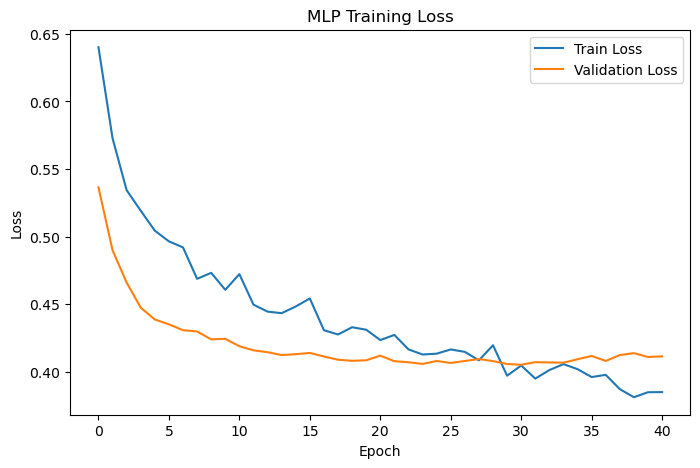

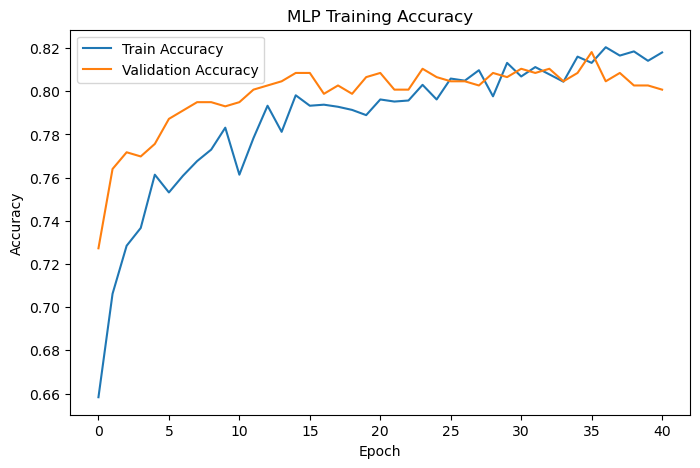

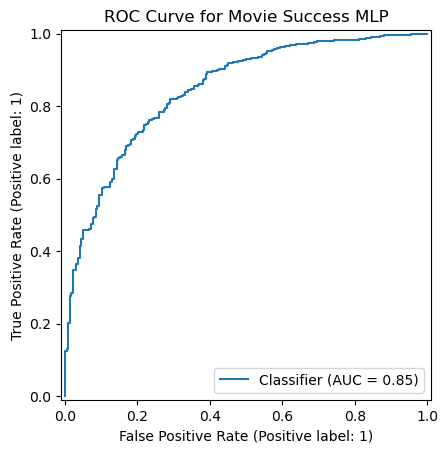


Sample predictions:
      actual_success  predicted_probability  predicted_class
597                1               0.907105                1
3897               1               0.041788                0
3606               1               0.768287                1
778                0               0.495760                0
2016               0               0.479882                0
2632               0               0.228871                0
1815               1               0.994355                1
1176               1               0.603987                1
1723               1               0.855463                1
2366               0               0.247064                0


In [1]:
# Predicting Movie Success with an MLP
# Dataset: tmdb_5000_movies.csv
# Target: success = 1 if revenue / budget > 1.5, else 0

import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Keras 3 imports
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import EarlyStopping


# 1. Load data

df = pd.read_csv("tmdb_5000_movies.csv")

print("Original shape:", df.shape)
print(df.head())


# 2. Basic cleaning

# Keep rows with positive budget so ROI is valid
df = df[df["budget"] > 0].copy()

# Keep rows with positive revenue too
df = df[df["revenue"] > 0].copy()

# Fill runtime if missing
df["runtime"] = df["runtime"].fillna(df["runtime"].median())

# Drop missing release_date
df = df.dropna(subset=["release_date"]).copy()


# 3. Create target variable

# ROI is defined as revenue / budget
df["roi"] = df["revenue"] / df["budget"] 

# A movie is considered successful if it generates at least 150% of its budget in revenue
df["success"] = (df["roi"] > 1.5).astype(int)

print("\nClass balance:")
print(df["success"].value_counts())
print(df["success"].value_counts(normalize=True))


# 4. Parse genres

def extract_names(x):
    try:
        items = ast.literal_eval(x)
        return [item["name"] for item in items]
    except:
        return []

df["genres_list"] = df["genres"].apply(extract_names)

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df["genres_list"])
genre_df = pd.DataFrame(
    genre_matrix,
    columns=[f"genre_{g}" for g in mlb.classes_],
    index=df.index
)

df = pd.concat([df, genre_df], axis=1)


# 5. Release date features

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"]).copy()

df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month


# 6. Language dummies

top_langs = df["original_language"].value_counts().nlargest(10).index
df["lang_grouped"] = np.where(
    df["original_language"].isin(top_langs),
    df["original_language"],
    "other"
)

lang_dummies = pd.get_dummies(df["lang_grouped"], prefix="lang", drop_first=True)
df = pd.concat([df, lang_dummies], axis=1)


# 7. Numeric feature engineering

df["log_budget"] = np.log1p(df["budget"])
df["log_popularity"] = np.log1p(df["popularity"])
df["log_vote_count"] = np.log1p(df["vote_count"])

numeric_features = [
    "log_budget",
    "runtime",
    "log_popularity",
    "vote_average",
    "log_vote_count",
    "release_year",
    "release_month"
]

genre_features = list(genre_df.columns)
language_features = list(lang_dummies.columns)

feature_cols = numeric_features + genre_features + language_features
target_col = "success"


# 8. Build X and y

X = df[feature_cols].copy()
y = df[target_col].copy()

# Make sure all are numeric
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)


# 9. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 10. Scale features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 11. Build MLP model

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


# 12. Train model

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


# 13. Evaluate model

y_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print("\nTest Results")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1 Score :", round(f1, 4))
print("ROC AUC  :", round(auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


# 14. Plot training history

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Training Accuracy")
plt.legend()
plt.show()

# 15. ROC curve

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve for Movie Success MLP")
plt.show()

# 16. Inspect sample predictions

results = X_test.copy()
results["actual_success"] = y_test.values
results["predicted_probability"] = y_prob
results["predicted_class"] = y_pred

print("\nSample predictions:")
print(results[["actual_success", "predicted_probability", "predicted_class"]].head(10))

In [2]:
# Post-Model Analysis: Predictions and Insights

# Create full results dataframe
results = df.copy()

# Scale full feature set
X_scaled_all = scaler.transform(X)

# Get predicted probabilities
results["predicted_probability"] = model.predict(X_scaled_all).ravel()

# Predicted class
results["predicted_class"] = (results["predicted_probability"] >= 0.5).astype(int)

# 1. Top predicted successful movies

print("\nTop Predicted Successful Movies:")
top_movies = results.sort_values("predicted_probability", ascending=False)

print(top_movies[[
    "title",
    "predicted_probability",
    "revenue",
    "budget"
]].head(10))


# 2. Compare predicted vs actual

print("\nTop Predictions with Actual Outcomes:")
print(top_movies[[
    "title",
    "predicted_probability",
    "success"
]].head(10))


# 3. False Positives (predicted success but failed)

print("\nFalse Positives (looked like hits but failed):")
false_positives = results[
    (results["predicted_probability"] > 0.8) &
    (results["success"] == 0)
]

print(false_positives[[
    "title",
    "predicted_probability",
    "budget",
    "revenue"
]].head(10))


# 4. False Negatives (predicted failure but succeeded)

print("\nFalse Negatives (unexpected hits):")
false_negatives = results[
    (results["predicted_probability"] < 0.2) &
    (results["success"] == 1)
]

print(false_negatives[[
    "title",
    "predicted_probability",
    "budget",
    "revenue"
]].head(10))


# 5. Most confident predictions

results["confidence"] = abs(results["predicted_probability"] - 0.5)

most_confident = results.sort_values("confidence", ascending=False)

print("\nMost Confident Predictions:")
print(most_confident[[
    "title",
    "predicted_probability"
]].head(10))

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Top Predicted Successful Movies:
                                title  predicted_probability    revenue  \
4198                     The Lunchbox               0.999976    4235151   
4238                     Modern Times               0.999960    8500000   
4329                       Casablanca               0.999912   10462500   
4259  Snow White and the Seven Dwarfs               0.999904  184925486   
3543                  Rang De Basanti               0.999800   11502151   
4441                            Bambi               0.999712  267447150   
3813               Gone with the Wind               0.999644  400176459   
4006              Singin' in the Rain               0.999538    7200000   
4604            It Happened One Night               0.999441    4500000   
809                      Forrest Gump               0.999441  677945399   

        budget  
4198   1000000  
4238         1  
4329    878000  
4259   1488423  
3543   2200000